<a href="https://colab.research.google.com/github/Biilzaa/TugasPraktikumANN--AI/blob/main/TugasPraktikumANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA: MUHAMMAD DIWAN ALFARABI,                                      NIM: 09020624050

KLASIFIKASI HARGA SMARTPHONE MENGGUNAKAN ARTIFICIAL NEURAL NETWORK (ANN)

Perkembangan teknologi smartphone menyebabkan munculnya berbagai jenis perangkat dengan spesifikasi dan harga yang berbeda-beda. Penentuan kategori harga smartphone dapat dilakukan menggunakan teknologi Artificial Intelligence, salah satunya dengan metode Artificial Neural Network (ANN).

ANN merupakan metode pembelajaran mesin yang meniru cara kerja jaringan saraf manusia dalam mengenali pola data. Pada penelitian ini, ANN digunakan untuk mengklasifikasikan kategori harga smartphone berdasarkan spesifikasi perangkat seperti RAM, baterai, memori internal, dan resolusi layar.

Dataset yang digunakan berasal dari Kaggle yaitu Mobile Price Classification Dataset. Tujuan penelitian ini adalah membangun model ANN yang mampu memprediksi kategori harga smartphone secara otomatis dengan tingkat akurasi yang baik.

Tahap 1. Import Library

Tahap pertama dalam proses implementasi adalah mengimpor library yang dibutuhkan. Library pandas digunakan untuk membaca dan mengelola dataset, numpy digunakan untuk pengolahan data numerik, sedangkan matplotlib digunakan untuk visualisasi grafik.

Library scikit-learn digunakan untuk preprocessing data, pembagian dataset, dan evaluasi model. TensorFlow Keras digunakan untuk membangun model Artificial Neural Network (ANN).

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Tahap 2. Membaca Dataset

Dataset yang telah diupload ke Google Colab dibaca menggunakan library pandas untuk melihat isi data dan struktur dataset. File yang digunakan adalah train.csv karena memiliki fitur input dan target klasifikasi yaitu kolom price_range.

In [24]:
df = pd.read_csv('train.csv')

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Tahap 3. Menampilkan Informasi Dataset

Tahap ini dilakukan untuk mengetahui jumlah data, tipe data, statistik data, serta mengecek apakah terdapat missing value pada dataset. Pemeriksaan dataset penting dilakukan agar model ANN dapat bekerja dengan baik tanpa adanya data kosong atau kesalahan format data.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [26]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [27]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


Tahap 4. Menentukan Fitur dan Target

Dataset terdiri dari fitur input dan target output. Variabel X digunakan sebagai fitur input yang akan dipelajari oleh model ANN, sedangkan variabel y digunakan sebagai target klasifikasi.

Kolom price_range digunakan sebagai target karena berisi kategori harga smartphone.

In [28]:
X = df.drop('price_range', axis=1)
y = df['price_range']

Tahap 5. Membagi Data Training dan Testing

Dataset dibagi menjadi data training dan data testing menggunakan train_test_split. Data training digunakan untuk melatih model ANN sedangkan data testing digunakan untuk mengevaluasi performa model setelah proses training selesai.

Sebanyak 80% data digunakan untuk training dan 20% digunakan untuk testing.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Tahap 6. Normalisasi Data

Normalisasi dilakukan menggunakan StandardScaler agar seluruh fitur memiliki skala yang seimbang. Proses ini penting karena ANN bekerja lebih optimal ketika seluruh data berada pada rentang nilai yang seragam.

Tanpa normalisasi, fitur dengan nilai besar dapat mempengaruhi proses pelatihan model secara tidak seimbang.

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Tahap 7. Membuat Model Artificial Neural Network (ANN)

Model Artificial Neural Network dibuat menggunakan Sequential dari TensorFlow Keras. Layer Input digunakan untuk menentukan jumlah fitur input pada dataset. Hidden layer menggunakan fungsi aktivasi ReLU untuk membantu model mempelajari pola data, sedangkan output layer menggunakan Softmax karena klasifikasi terdiri dari empat kategori harga smartphone.

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(4, activation='softmax'))

Tahap 8. Compile Model

Model dikompilasi menggunakan optimizer Adam dan fungsi loss sparse categorical crossentropy. Optimizer Adam digunakan karena mampu mempercepat proses training model, sedangkan sparse categorical crossentropy digunakan karena target klasifikasi terdiri dari beberapa kelas.

In [32]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Tahap 9. Training Model

Model ANN dilatih menggunakan data training selama 50 epoch. Pada tahap ini model akan mempelajari pola hubungan antara spesifikasi smartphone dan kategori harga.

Validation split digunakan untuk memantau performa model selama proses training berlangsung.

In [33]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2812 - loss: 1.3999 - val_accuracy: 0.3063 - val_loss: 1.3613
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3219 - loss: 1.3285 - val_accuracy: 0.3469 - val_loss: 1.3160
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3812 - loss: 1.2700 - val_accuracy: 0.3938 - val_loss: 1.2660
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4445 - loss: 1.2006 - val_accuracy: 0.4781 - val_loss: 1.1929
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5180 - loss: 1.1107 - val_accuracy: 0.5219 - val_loss: 1.0996
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5883 - loss: 1.0079 - val_accuracy: 0.5781 - val_loss: 1.0004
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6430 - loss: 0.9039 - val_accuracy: 0.6125 - val_loss: 0.9079
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6953 - loss: 0.8080 - val_accuracy: 0.6531 - val_loss:

Tahap 10. Visualisasi Accuracy Model

Grafik accuracy digunakan untuk melihat perkembangan performa model selama proses training. Semakin tinggi nilai accuracy maka semakin baik kemampuan model dalam melakukan klasifikasi data.

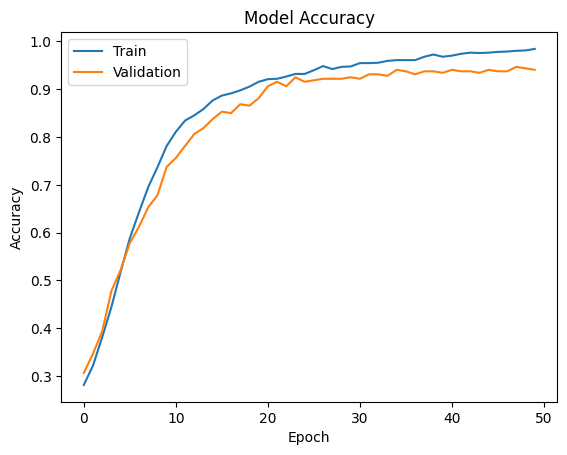

In [34]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

Tahap 11. Evaluasi Model

Tahap evaluasi dilakukan menggunakan data testing untuk mengetahui tingkat akurasi model ANN dalam melakukan klasifikasi kategori harga smartphone.

In [35]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9175 - loss: 0.2085  
Accuracy: 0.9175000190734863


Tahap 12. Prediksi Data

Model yang telah dilatih digunakan untuk melakukan prediksi terhadap data testing. Hasil prediksi berupa kategori harga smartphone berdasarkan spesifikasi perangkat.

In [36]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[0 2 1 3 1 1 2 0 3 1]


Tahap 13. Confusion Matrix

Confusion matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada setiap kategori kelas. Matriks ini membantu mengetahui performa model secara lebih detail.

In [37]:
cm = confusion_matrix(y_test, predicted_classes)

print(cm)

[[ 97   8   0   0]
 [  2  88   1   0]
 [  0   7  78   7]
 [  0   0   8 104]]


Tahap 14. Classification Report

Classification report digunakan untuk melihat nilai precision, recall, f1-score, dan accuracy dari model ANN. Nilai tersebut digunakan untuk mengevaluasi kualitas klasifikasi pada masing-masing kategori harga smartphone.

In [38]:
print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       105
           1       0.85      0.97      0.91        91
           2       0.90      0.85      0.87        92
           3       0.94      0.93      0.93       112

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



Tahap 15. Analisis Hasil

Berdasarkan hasil pengujian, model Artificial Neural Network berhasil melakukan klasifikasi kategori harga smartphone dengan tingkat akurasi yang tinggi. Hal ini menunjukkan bahwa ANN mampu mempelajari pola hubungan antara spesifikasi smartphone dan kategori harga secara baik.

Fitur seperti RAM, kapasitas baterai, dan resolusi layar memiliki pengaruh terhadap hasil klasifikasi. Grafik accuracy menunjukkan bahwa performa model meningkat selama proses training dan model tidak mengalami overfitting yang signifikan.

Hasil confusion matrix dan classification report menunjukkan bahwa sebagian besar data berhasil diprediksi dengan benar oleh model ANN.

Tahap 16. Kesimpulan

Metode Artificial Neural Network (ANN) berhasil digunakan untuk melakukan klasifikasi harga smartphone berdasarkan spesifikasi perangkat. Model mampu menghasilkan performa klasifikasi yang baik dengan tingkat akurasi tinggi sehingga dapat digunakan untuk membantu proses prediksi kategori harga smartphone secara otomatis.